In [36]:
# Import necessary libraries
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
# Define file paths
models_folder = "../models"
processed_folder = "../data/processed"

input_file = os.path.join(processed_folder, "nhs_ae_model_ready_with_features.csv")
xgb_predictions_file = os.path.join(processed_folder, "xgb_forecast_predictions.csv")
xgb_feature_importance_file = os.path.join(processed_folder, "xgb_feature_importance.csv")

In [38]:
# Load model-ready dataset
df_model = pd.read_csv(input_file)
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values(["org_code", "period"]).reset_index(drop=True)

df_model.head()

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,...,quarter,month_sin,month_cos,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3
0,2021-04-01,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,155,0,0,0,...,2,8.660254e-01,-0.500000,191.0,102.0,155.0,99.0,139.333333,138.833333,46.198846
1,2021-05-01,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,180,0,0,0,...,2,5.000000e-01,-0.866025,155.0,125.0,147.0,130.0,157.000000,138.833333,33.045423
2,2021-06-01,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,255,0,0,0,...,2,1.224647e-16,-1.000000,180.0,191.0,113.0,181.0,175.333333,144.333333,18.448125
3,2021-07-01,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,203,0,0,0,...,3,-5.000000e-01,-0.866025,255.0,155.0,102.0,203.0,196.666667,168.000000,52.041650
4,2021-08-01,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,204,0,0,0,...,3,-8.660254e-01,-0.500000,203.0,180.0,125.0,189.0,212.666667,184.833333,38.423083


In [39]:
# Define target and features
target = "total_attendances"

features = [
    "year",
    "month",
    "quarter",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3",
    "total_over_4hrs",
    "total_emergency_admissions",
    "total_booked_attendances",
    "total_dta_waits"
]

In [40]:
# Train-test split
split_date = pd.Timestamp("2025-04-01")

train = df_model[df_model["period"] < split_date].copy()
test = df_model[df_model["period"] >= split_date].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [41]:
# Train XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [42]:
# Evaluate model
test["xgb_prediction"] = xgb_model.predict(X_test)
test[["org_code", "org_name", "period", "total_attendances", "xgb_prediction"]].head()

,org_code,org_name,period,total_attendances,xgb_prediction
47,AAH,TETBURY HOSPITAL TRUST LTD,2025-04-01,536,681.756958
48,AAH,TETBURY HOSPITAL TRUST LTD,2025-05-01,524,598.010315
49,AAH,TETBURY HOSPITAL TRUST LTD,2025-06-01,611,476.949677
50,AAH,TETBURY HOSPITAL TRUST LTD,2025-07-01,688,657.195618
51,AAH,TETBURY HOSPITAL TRUST LTD,2025-08-01,482,689.114868


In [43]:
# Calculate evaluation metrics
xgb_mae = mean_absolute_error(y_test, test["xgb_prediction"])
xgb_rmse = np.sqrt(mean_squared_error(y_test, test["xgb_prediction"]))
xgb_r2 = r2_score(y_test, test["xgb_prediction"])

print(f"XGBoost MAE: {xgb_mae:,.2f}")
print(f"XGBoost RMSE: {xgb_rmse:,.2f}")
print(f"XGBoost R²: {xgb_r2:.4f}")

XGBoost MAE: 416.17
XGBoost RMSE: 701.70
XGBoost R²: 0.9945


In [44]:
# Feature importance
xgb_feature_importance = pd.DataFrame({
    "feature": features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_feature_importance

,feature,importance
9,rolling_mean_3,0.534739
5,lag_1,0.433397
10,rolling_mean_6,0.011082
3,month_sin,0.003066
7,lag_6,0.002722
8,lag_12,0.002058
11,rolling_std_3,0.001976
12,total_over_4hrs,0.001955
13,total_emergency_admissions,0.001796
1,month,0.001786


In [45]:
# Save predictions and feature importance
xgb_feature_importance.to_csv(xgb_feature_importance_file, index=False)
test.to_csv(xgb_predictions_file, index=False)

print(f"Saved XGBoost predictions to: {xgb_predictions_file}")
print(f"Saved XGBoost feature importance to: {xgb_feature_importance_file}")

Saved XGBoost predictions to: ../data/processed/xgb_forecast_predictions.csv
Saved XGBoost feature importance to: ../data/processed/xgb_feature_importance.csv


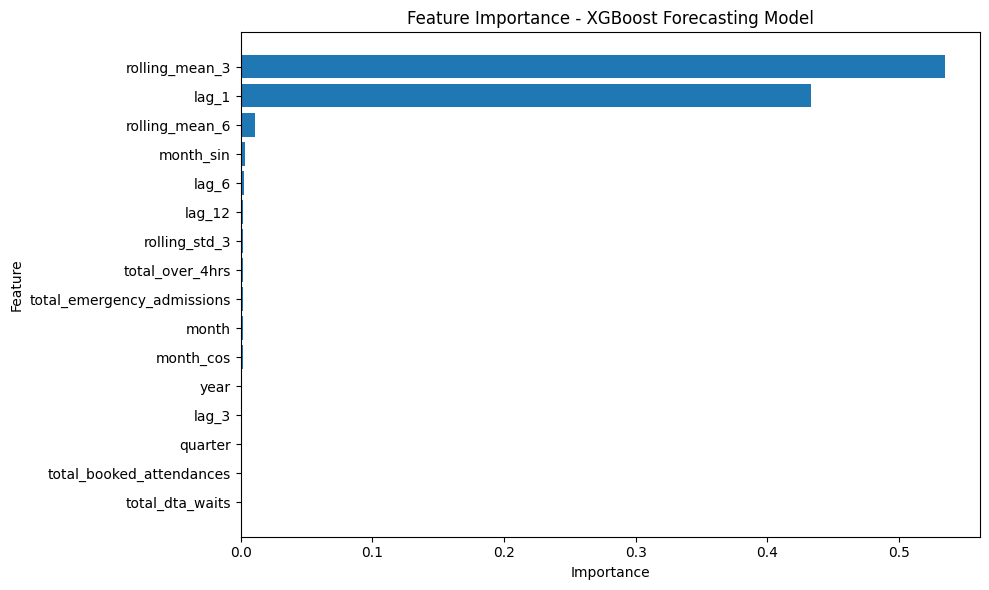

In [46]:
# Plot XGBoost feature importance
plt.figure(figsize=(10, 6))
plt.barh(xgb_feature_importance["feature"], xgb_feature_importance["importance"])
plt.title("Feature Importance - XGBoost Forecasting Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [47]:
# Save XGBoost evaluation metrics
xgb_metrics = pd.DataFrame([{
    "model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse,
    "R2": xgb_r2
}])

xgb_metrics.to_csv("../data/processed/xgboost_metrics.csv", index=False)
print("Saved XGBoost metrics.")

Saved XGBoost metrics.


In [48]:
# Save trained XGBoost model artifact
xgb_model.save_model(os.path.join(models_folder, "xgboost_model.json"))
print("Saved XGBoost model.")

Saved XGBoost model.
